# 06 - Results Review Dashboard

This notebook centralizes model results, videos, extracted frames, temporal risk curves, alert predictions, and evaluation KPIs for qualitative and scientific analysis.

## What You Can Inspect Here

- Original sampled dashcam videos.
- Extracted frames used in the baseline.
- Frame-level model predictions.
- Temporal risk curves across videos.
- Predicted alert time versus true alert/event timestamps.
- Alert KPIs and threshold trade-offs.
- False positives, false negatives, and high-risk examples.

In [1]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import HTML, Image, Video, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

sample_csv = PROJECT_ROOT / "data" / "interim" / "sample_100_videos.csv"
frames_manifest_csv = PROJECT_ROOT / "data" / "interim" / "sample_frames_manifest.csv"
frame_predictions_csv = PROJECT_ROOT / "outputs" / "predictions" / "baseline_frame_predictions.csv"
video_predictions_csv = PROJECT_ROOT / "outputs" / "predictions" / "baseline_video_predictions.csv"
risk_scores_csv = PROJECT_ROOT / "outputs" / "predictions" / "temporal_risk_scores.csv"
alert_predictions_csv = PROJECT_ROOT / "outputs" / "predictions" / "alert_predictions.csv"
baseline_metrics_json = PROJECT_ROOT / "models" / "reports" / "baseline_metrics.json"
alert_metrics_json = PROJECT_ROOT / "models" / "reports" / "alert_metrics.json"
threshold_sweep_csv = PROJECT_ROOT / "models" / "reports" / "alert_threshold_sweep.csv"
figures_dir = PROJECT_ROOT / "outputs" / "figures"

PROJECT_ROOT

WindowsPath('c:/Users/z004hn4c/Documents/Estudo/LLMOps And AIOps Bootcamp With 8 End To End Projects/nexar-dashcam-collision-prediction')

In [2]:
sample_df = pd.read_csv(sample_csv, dtype={"id": str})
frames_df = pd.read_csv(frames_manifest_csv, dtype={"id": str})
risk_scores_df = pd.read_csv(risk_scores_csv, dtype={"id": str})
alert_predictions_df = pd.read_csv(alert_predictions_csv, dtype={"id": str})
threshold_sweep_df = pd.read_csv(threshold_sweep_csv)

baseline_metrics = json.loads(baseline_metrics_json.read_text(encoding="utf-8"))
alert_metrics = json.loads(alert_metrics_json.read_text(encoding="utf-8"))

sample_df.shape, frames_df.shape, risk_scores_df.shape, alert_predictions_df.shape

((100, 6), (500, 8), (3912, 5), (100, 9))

## Global Model Metrics

In [3]:
baseline_summary = pd.DataFrame(
    [
        {"level": "frame", **baseline_metrics["frame_metrics"]},
        {"level": "video_mean", **baseline_metrics["video_metrics_mean"]},
        {"level": "video_max", **baseline_metrics["video_metrics_max"]},
    ]
)

display(baseline_summary)
display(pd.DataFrame([alert_metrics["metrics"]]).T.rename(columns={0: "value"}))

,level,accuracy,precision,recall,f1,roc_auc
0,frame,0.55,0.538462,0.7,0.608696,0.5604
1,video_mean,0.55,0.538462,0.7,0.608696,0.6200
2,video_max,0.45,0.466667,0.7,0.560000,0.5300


,value
videos,100.000000
positive_videos,50.000000
negative_videos,50.000000
predicted_alerts,91.000000
true_positive_alerts,49.000000
false_positive_alerts,42.000000
missed_events,1.000000
alert_precision,0.538462
alert_recall,0.980000
false_alarm_rate,0.840000


## Global Figures

baseline_frame_confusion_matrix.png


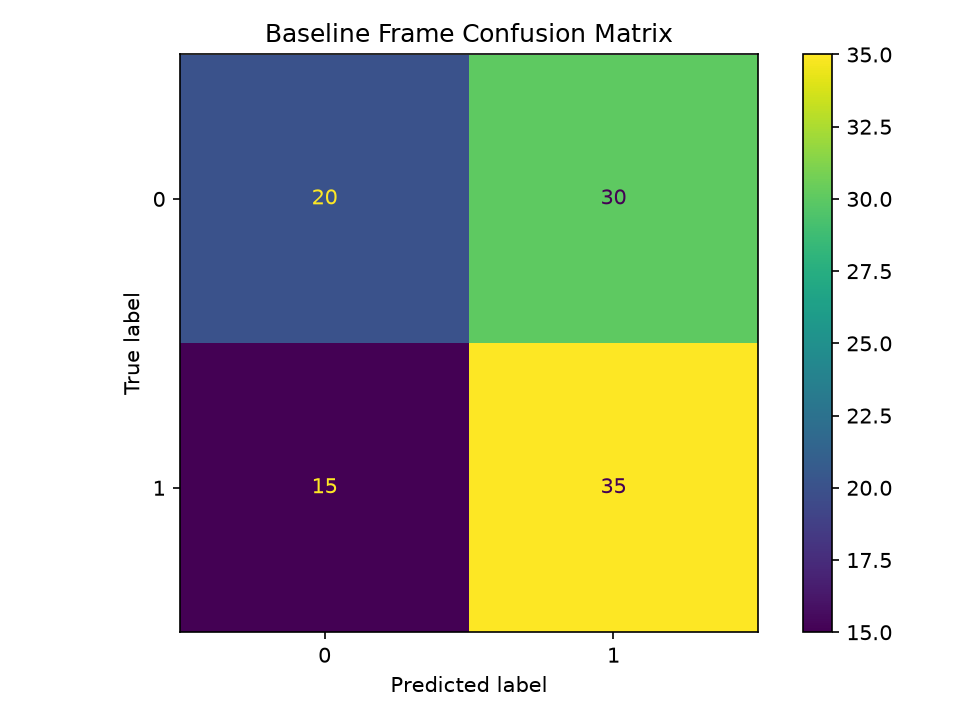

baseline_frame_roc_curve.png


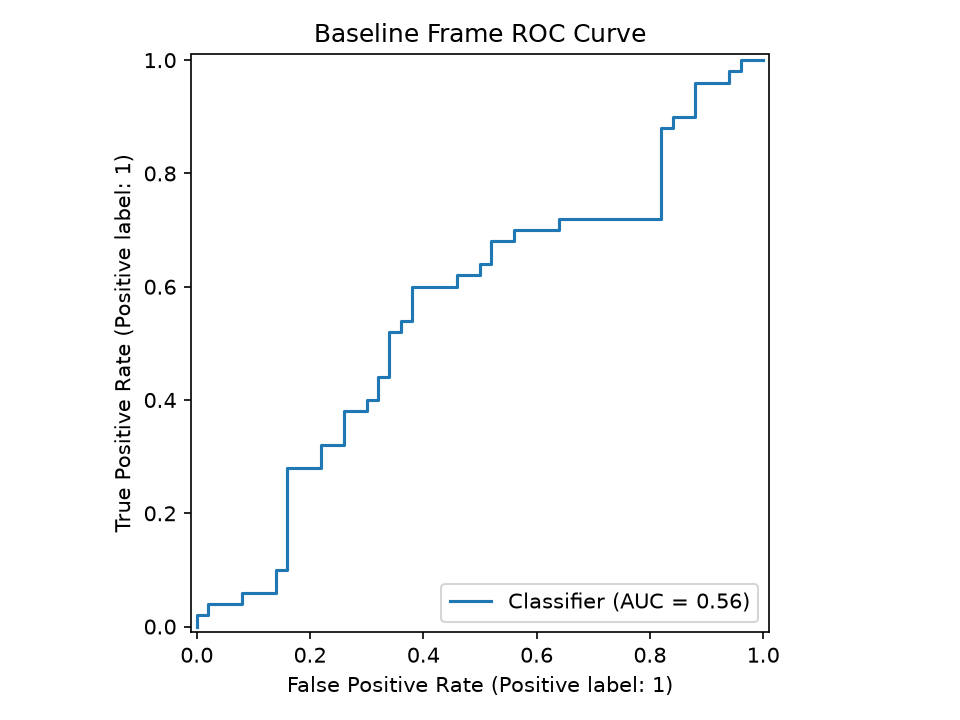

alert_threshold_sweep.png


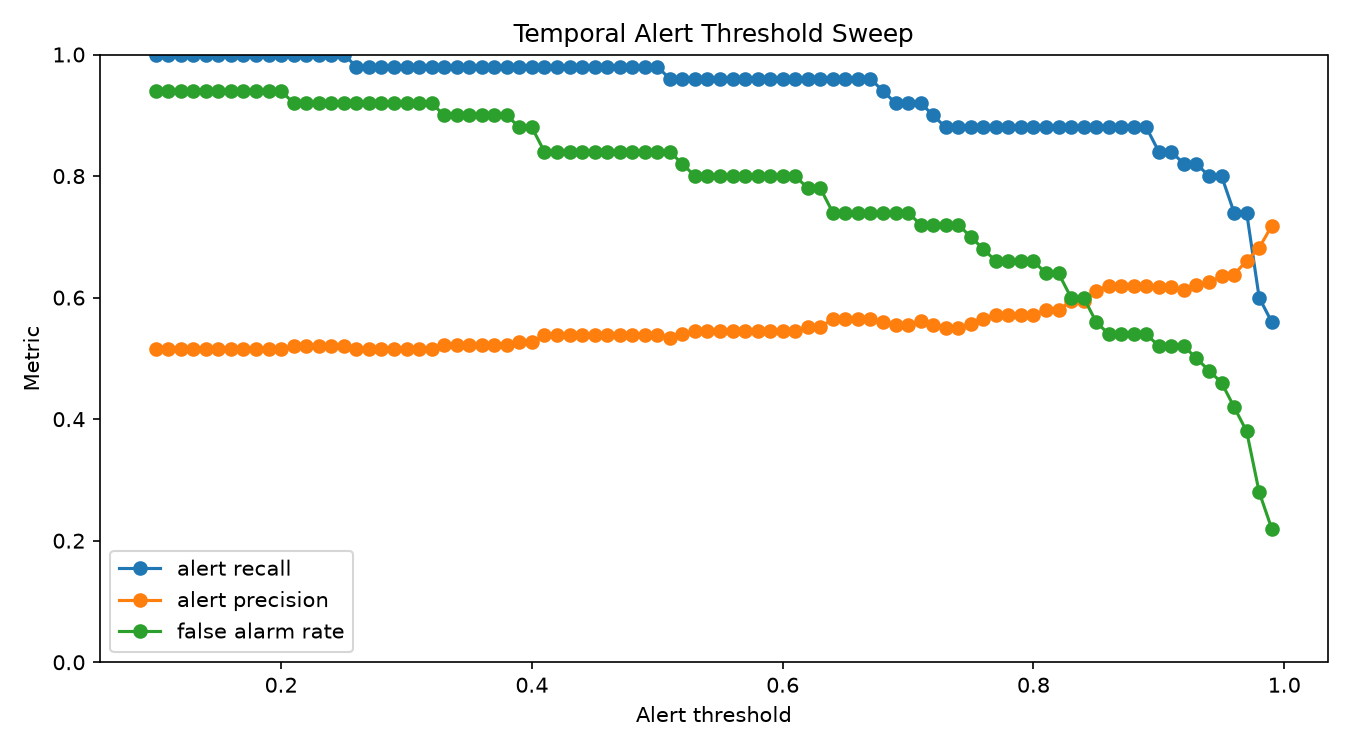

In [4]:
for figure_name in [
    "baseline_frame_confusion_matrix.png",
    "baseline_frame_roc_curve.png",
    "alert_threshold_sweep.png",
]:
    figure_path = figures_dir / figure_name
    print(figure_path.name)
    display(Image(filename=str(figure_path)))

## Select A Video To Inspect

Change `video_id` below to inspect another video. Good starting examples:

- Positive example: `00364`
- Negative example: `01840`

You can also choose IDs from the tables in later sections.

In [5]:
video_id = "00364"

video_row = sample_df[sample_df["id"] == video_id].iloc[0]
alert_row = alert_predictions_df[alert_predictions_df["id"] == video_id].iloc[0]
video_path = Path(video_row["video_path"])

summary = pd.DataFrame([{
    "id": video_id,
    "target": int(video_row["target"]),
    "time_of_alert": video_row.get("time_of_alert"),
    "time_of_event": video_row.get("time_of_event"),
    "predicted_alert_time": alert_row["predicted_alert_time"],
    "predicted_lead_time": alert_row["predicted_lead_time"],
    "alert_time_error": alert_row["alert_time_error"],
    "max_risk_score": alert_row["max_risk_score"],
    "mean_risk_score": alert_row["mean_risk_score"],
    "video_path": str(video_path),
}])

display(summary)

,id,target,time_of_alert,time_of_event,predicted_alert_time,predicted_lead_time,alert_time_error,max_risk_score,mean_risk_score,video_path
0,00364,1,19.447,20.427,0.0,20.427,-19.447,0.918959,0.768162,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...


## Original Video

In [6]:
display(Video(filename=str(video_path), embed=False, width=720))

## Extracted Frames For This Video

,id,target,frame_label,timestamp,frame_path
15,00364,1,event_minus_5s,15.427,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...
16,00364,1,event_minus_3s,17.427,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...
17,00364,1,event_minus_1s,19.427,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...
18,00364,1,alert,19.447,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...
19,00364,1,event,20.427,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...


event_minus_5s | t=15.427s


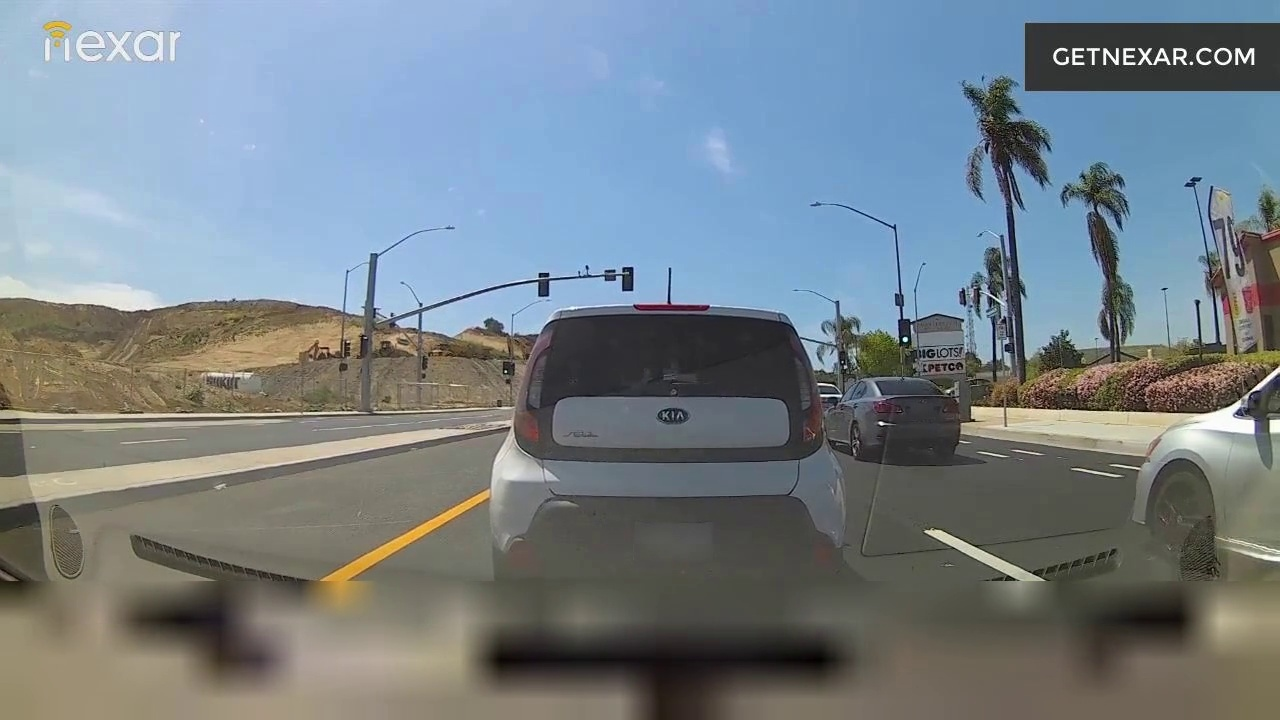

event_minus_3s | t=17.427s


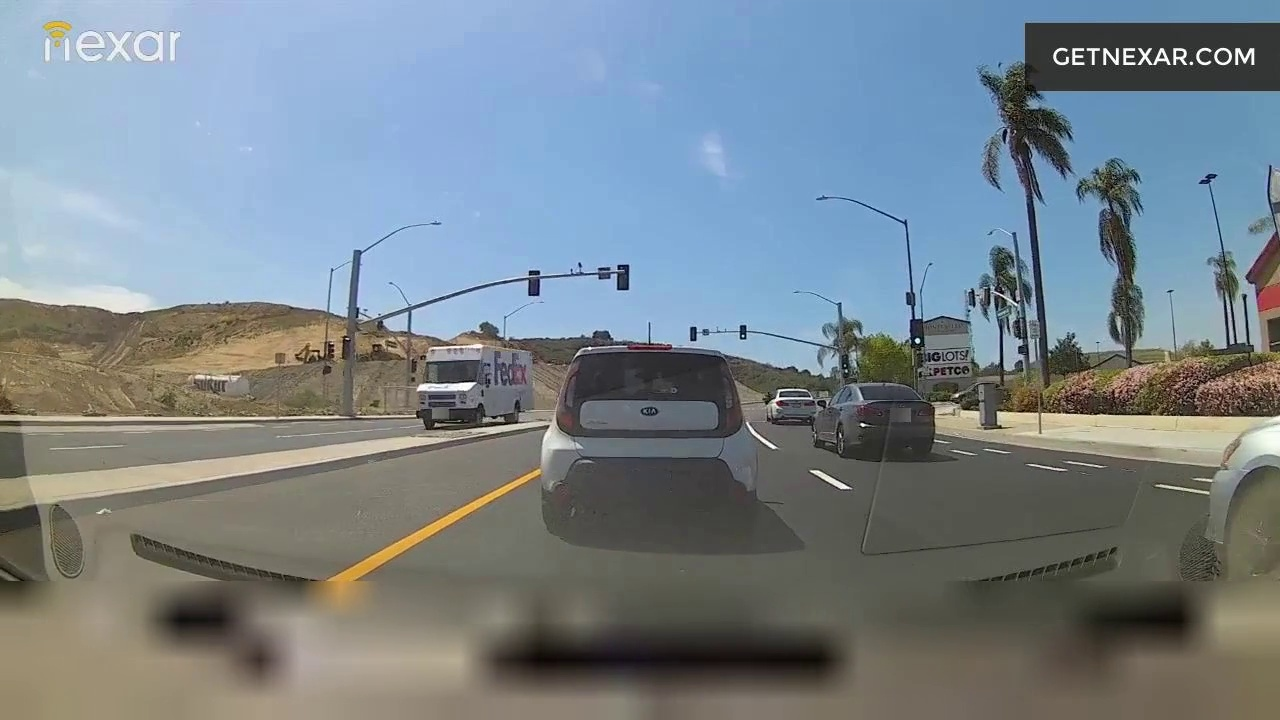

event_minus_1s | t=19.427s


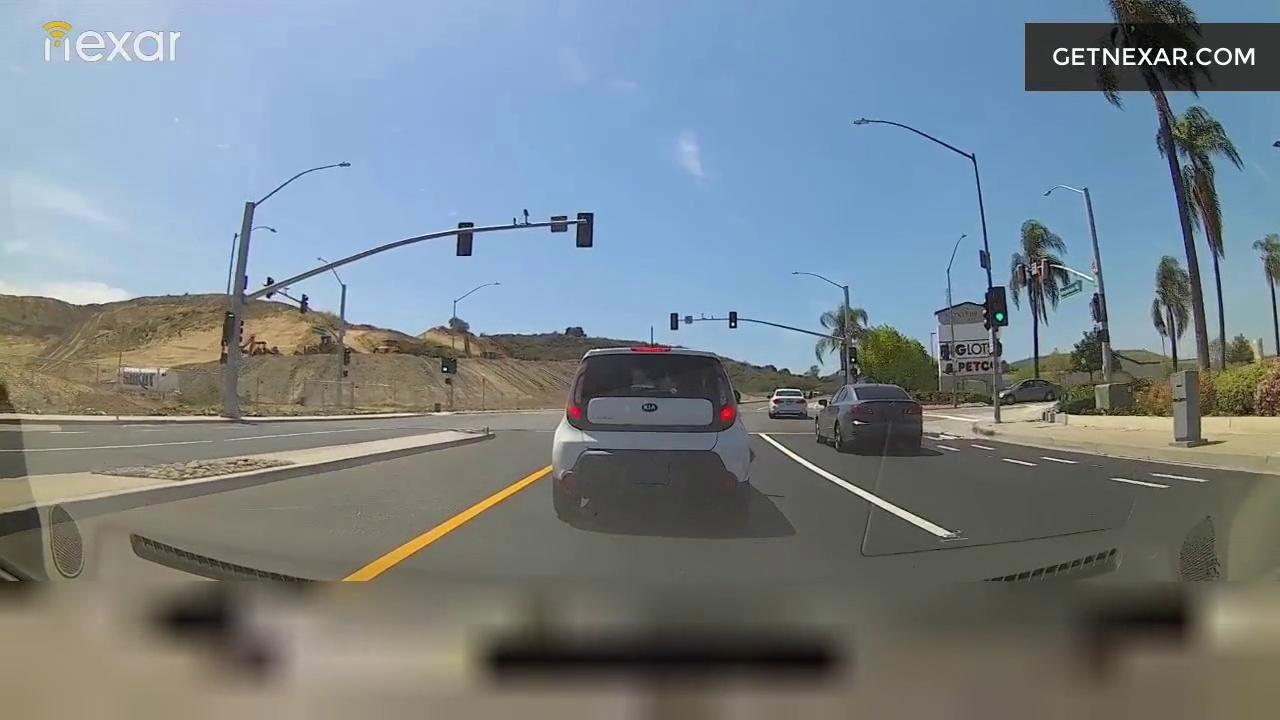

alert | t=19.447s


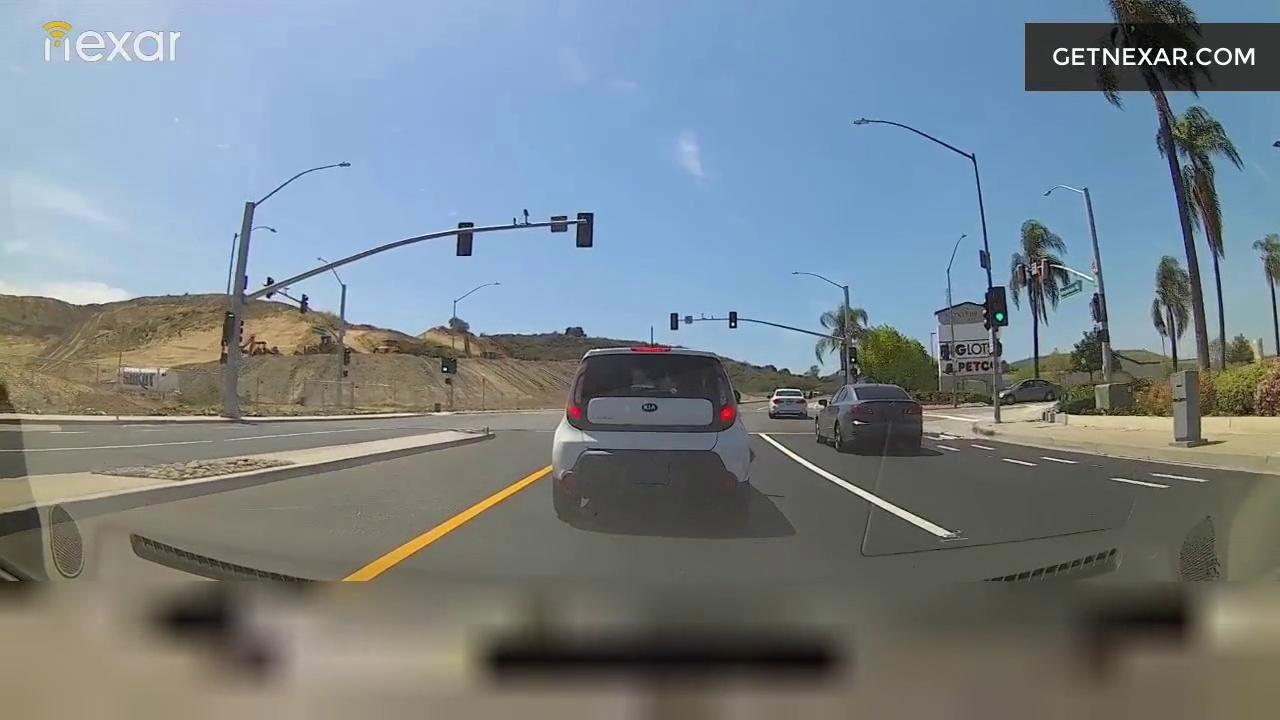

event | t=20.427s


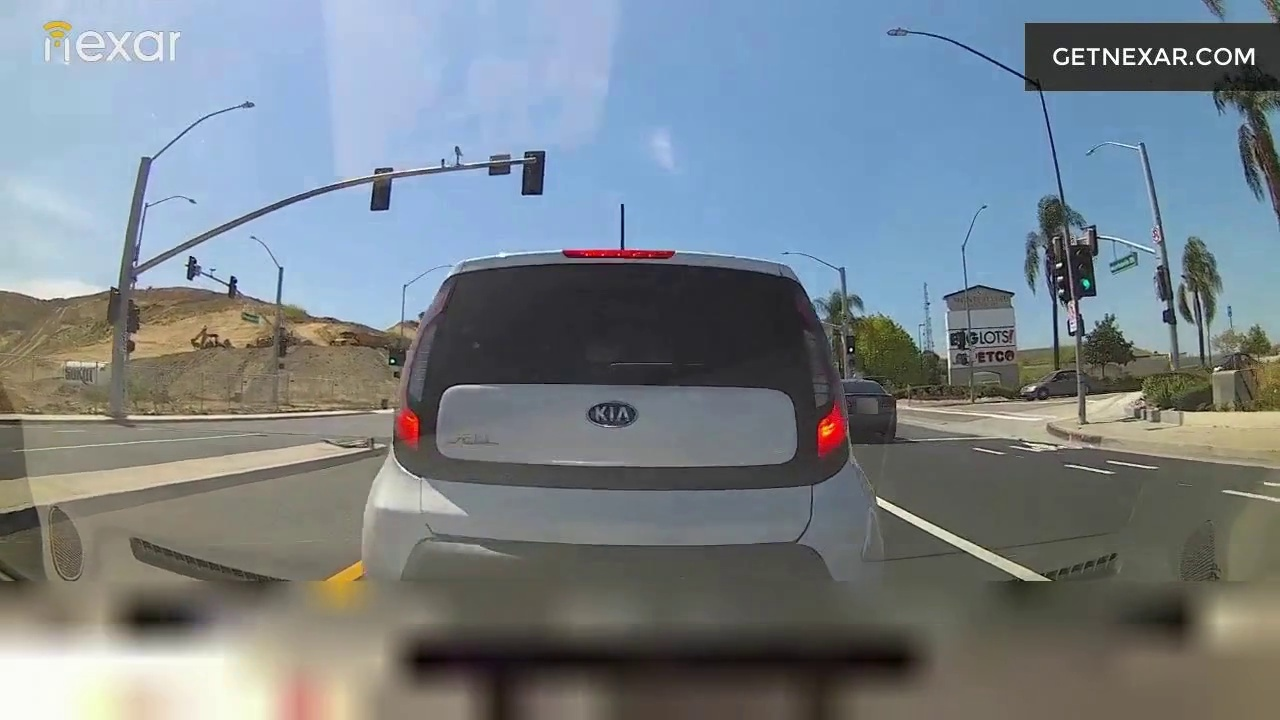

In [7]:
video_frames = frames_df[frames_df["id"] == video_id].sort_values("timestamp")
display(video_frames[["id", "target", "frame_label", "timestamp", "frame_path"]])

for _, row in video_frames.iterrows():
    print(f"{row['frame_label']} | t={row['timestamp']}s")
    display(Image(filename=row["frame_path"], width=640))

## Temporal Risk Curve For This Video

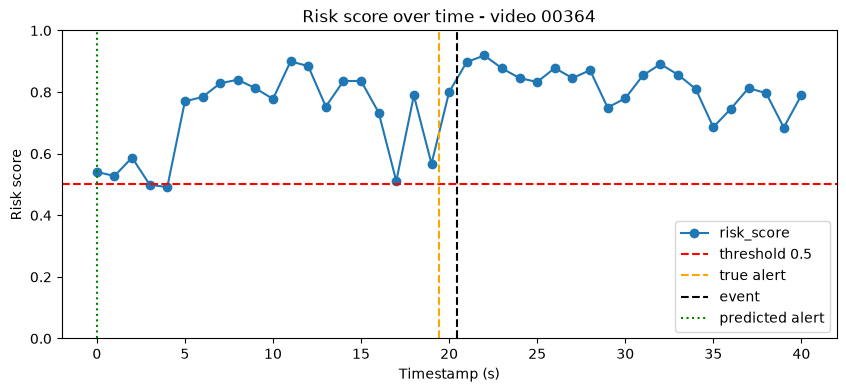

In [8]:
video_scores = risk_scores_df[risk_scores_df["id"] == video_id].sort_values("timestamp")

ax = video_scores.plot(
    x="timestamp",
    y="risk_score",
    figsize=(10, 4),
    marker="o",
    title=f"Risk score over time - video {video_id}",
)
ax.axhline(0.5, color="red", linestyle="--", label="threshold 0.5")

if int(video_row["target"]) == 1:
    ax.axvline(float(video_row["time_of_alert"]), color="orange", linestyle="--", label="true alert")
    ax.axvline(float(video_row["time_of_event"]), color="black", linestyle="--", label="event")

if pd.notna(alert_row["predicted_alert_time"]):
    ax.axvline(float(alert_row["predicted_alert_time"]), color="green", linestyle=":", label="predicted alert")

ax.set_ylim(0, 1)
ax.set_xlabel("Timestamp (s)")
ax.set_ylabel("Risk score")
ax.legend();

## Risk Score Table

In [9]:
video_scores.head(30)

,id,target,timestamp,risk_score,duration
100,00364,1,0.0,0.540918,40.525
101,00364,1,1.0,0.527514,40.525
102,00364,1,2.0,0.587401,40.525
103,00364,1,3.0,0.499334,40.525
104,00364,1,4.0,0.491551,40.525
105,00364,1,5.0,0.770093,40.525
106,00364,1,6.0,0.784015,40.525
107,00364,1,7.0,0.828484,40.525
108,00364,1,8.0,0.840188,40.525
109,00364,1,9.0,0.812637,40.525


## Find Interesting Cases

In [10]:
positive_alerts = alert_predictions_df[alert_predictions_df["target"] == 1].copy()
negative_alerts = alert_predictions_df[alert_predictions_df["target"] == 0].copy()

false_alarms = negative_alerts[negative_alerts["predicted_alert_time"].notna()].sort_values("max_risk_score", ascending=False)
missed_events = positive_alerts[positive_alerts["predicted_alert_time"].isna()]
earliest_positive_alerts = positive_alerts[positive_alerts["predicted_alert_time"].notna()].sort_values("alert_time_error")
latest_positive_alerts = positive_alerts[positive_alerts["predicted_alert_time"].notna()].sort_values("alert_time_error", ascending=False)

print("False alarms on negative videos")
display(false_alarms.head(10))

print("Missed positive events")
display(missed_events.head(10))

print("Earliest positive alerts compared with annotated alert")
display(earliest_positive_alerts.head(10))

print("Latest positive alerts compared with annotated alert")
display(latest_positive_alerts.head(10))

False alarms on negative videos


,id,target,time_of_alert,time_of_event,predicted_alert_time,predicted_lead_time,alert_time_error,max_risk_score,mean_risk_score
72,01542,0,NaN,NaN,0.0,NaN,NaN,0.999315,0.987777
37,01858,0,NaN,NaN,0.0,NaN,NaN,0.998377,0.635871
99,01071,0,NaN,NaN,0.0,NaN,NaN,0.997437,0.476586
78,01080,0,NaN,NaN,0.0,NaN,NaN,0.996538,0.862095
43,02034,0,NaN,NaN,0.0,NaN,NaN,0.996147,0.566366
57,01441,0,NaN,NaN,0.0,NaN,NaN,0.996068,0.401336
32,01801,0,NaN,NaN,0.0,NaN,NaN,0.993907,0.678022
34,01465,0,NaN,NaN,0.0,NaN,NaN,0.992926,0.367998
67,01970,0,NaN,NaN,2.0,NaN,NaN,0.992418,0.433088
36,01276,0,NaN,NaN,0.0,NaN,NaN,0.990836,0.861744


Missed positive events


,id,target,time_of_alert,time_of_event,predicted_alert_time,predicted_lead_time,alert_time_error,max_risk_score,mean_risk_score
87,00461,1,8.0,10.1,NaN,NaN,NaN,0.254011,0.098236


Earliest positive alerts compared with annotated alert


,id,target,time_of_alert,time_of_event,predicted_alert_time,predicted_lead_time,alert_time_error,max_risk_score,mean_risk_score
9,00579,1,21.549,22.752,0.0,22.752,-21.549,0.999751,0.988384
45,00816,1,20.200,21.267,0.0,21.267,-20.200,0.998998,0.804604
94,00097,1,19.916,19.949,0.0,19.949,-19.916,0.999958,0.999102
53,00587,1,19.533,20.733,0.0,20.733,-19.533,0.996000,0.921856
3,00364,1,19.447,20.427,0.0,20.427,-19.447,0.918959,0.768162
31,00339,1,19.347,20.545,0.0,20.545,-19.347,0.952754,0.704309
10,00703,1,19.033,20.733,0.0,20.733,-19.033,0.999644,0.912521
49,00519,1,19.033,19.567,0.0,19.567,-19.033,0.999231,0.973841
41,00909,1,18.998,21.302,0.0,21.302,-18.998,0.982944,0.644797
26,00477,1,18.833,20.000,0.0,20.000,-18.833,0.998141,0.951825


Latest positive alerts compared with annotated alert


,id,target,time_of_alert,time_of_event,predicted_alert_time,predicted_lead_time,alert_time_error,max_risk_score,mean_risk_score
54,00103,1,19.400,20.467,20.0,0.467,0.600,0.711692,0.261961
82,00345,1,17.933,19.467,16.0,3.467,-1.933,0.895905,0.157310
28,00242,1,19.433,20.567,15.0,5.567,-4.433,0.990750,0.564453
52,00131,1,18.645,19.581,14.0,5.581,-4.645,0.999314,0.741445
97,00904,1,18.523,19.209,11.0,8.209,-7.523,0.847552,0.485739
88,00967,1,7.629,9.362,0.0,9.362,-7.629,0.984647,0.883999
18,00783,1,20.350,21.265,12.0,9.265,-8.350,0.757632,0.380018
13,01031,1,9.067,9.633,0.0,9.633,-9.067,0.978369,0.927824
30,00324,1,19.167,20.050,10.0,10.050,-9.167,0.674522,0.239911
71,00733,1,11.469,15.194,0.0,15.194,-11.469,0.914400,0.625755


## Threshold Sweep Table

In [11]:
threshold_sweep_df[[
    "threshold",
    "alert_precision",
    "alert_recall",
    "false_alarm_rate",
    "missed_event_rate",
    "mean_predicted_lead_time",
    "mean_alert_time_error",
]].tail(20)

,threshold,alert_precision,alert_recall,false_alarm_rate,missed_event_rate,mean_predicted_lead_time,mean_alert_time_error
70,0.80,0.571429,0.88,0.66,0.12,17.198182,-15.538750
71,0.81,0.578947,0.88,0.64,0.12,16.970909,-15.311477
72,0.82,0.578947,0.88,0.64,0.12,16.766364,-15.106932
73,0.83,0.594595,0.88,0.60,0.12,16.743636,-15.084205
74,0.84,0.594595,0.88,0.60,0.12,16.652727,-14.993295
75,0.85,0.611111,0.88,0.56,0.12,16.561818,-14.902386
76,0.86,0.619718,0.88,0.54,0.12,16.334545,-14.675114
77,0.87,0.619718,0.88,0.54,0.12,16.266364,-14.606932
78,0.88,0.619718,0.88,0.54,0.12,15.970909,-14.311477
79,0.89,0.619718,0.88,0.54,0.12,15.811818,-14.152386


## Article Notes

Use this notebook to identify qualitative examples for the paper: true positives, false alarms, missed events, and cases where the model alerts much earlier than the annotated alert time. The current baseline is useful for demonstrating the pipeline, but its false alarm behavior shows why temporally refined labels and better calibration are necessary.